# 1. IMPORT LIBRARY

Basic Library

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

Machine Learning Library

In [48]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, roc_curve, precision_recall_curve,
                           accuracy_score, precision_score, recall_score, f1_score)

Chart Style

In [49]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. READ AND DATA MINNING

Read data

In [50]:
df = pd.read_excel('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/Data_For Midterm and Final Project.xlsx', sheet_name='saoke_td_ct')

General Information about data

In [51]:
print("=== BASIC INFORMATION ABOUT DATA ===")
print(f"Data size: {df.shape}")
print(f"Number of columns: {df.columns.tolist()}")
print(f"\nData type:\n{df.dtypes}")

=== BASIC INFORMATION ABOUT DATA ===
Data size: (90344, 22)
Number of columns: ['MJACCTTYPCD', 'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'CURRENCYCD', 'OPEN_DATE', 'NGAYDENHAN', 'ID_TIME', 'DESC_TIME', 'MJACCTTYPDESC', 'ORGNBR', 'ORGNAME', 'PARENTORGNBR', 'PARENTORGNAME', 'LAISUAT', 'MUCDICHVAY', 'NHOMNO', 'NHOMNOMOI', 'NHOMNO_TCBS']

Data type:
MJACCTTYPCD             object
PHUONG THUC CHO VAY     object
LOAIKH                   int64
SEX                     object
BASE_BAL               float64
CURR_BAL               float64
DUNO_QD                float64
CURRENCYCD              object
OPEN_DATE               object
NGAYDENHAN              object
ID_TIME                  int64
DESC_TIME               object
MJACCTTYPDESC           object
ORGNBR                   int64
ORGNAME                 object
PARENTORGNBR             int64
PARENTORGNAME           object
LAISUAT                float64
MUCDICHVAY              object
NHOMNO                   int64

Descriptive Statistics

In [52]:
print('=== DESCRIPTIVE STATISTICS ===')
print(df.describe())

=== DESCRIPTIVE STATISTICS ===
             LOAIKH      BASE_BAL      CURR_BAL       DUNO_QD       ID_TIME  \
count  90344.000000  9.034400e+04  9.034400e+04  9.034400e+04  90344.000000   
mean       1.015950  3.824727e+08  3.492253e+08  3.504023e+08      1.306041   
std        0.125283  4.389216e+09  3.828898e+09  3.830033e+09      0.615677   
min        1.000000  2.000000e+00  1.000000e+00  1.000000e+00      1.000000   
25%        1.000000  2.200000e+07  3.000000e+07  3.000000e+07      1.000000   
50%        1.000000  1.200000e+08  1.100000e+08  1.100000e+08      1.000000   
75%        1.000000  3.000000e+08  3.000000e+08  3.000000e+08      1.000000   
max        2.000000  3.850000e+11  3.127000e+11  3.127000e+11      3.000000   

             ORGNBR  PARENTORGNBR       LAISUAT        NHOMNO     NHOMNOMOI  
count  90344.000000  90344.000000  90344.000000  90344.000000  90344.000000  
mean      62.705703     44.470435      0.090739      1.260183      1.278491  
std       36.059407    

Check for missing data

In [53]:
print("\n=== MISSING DATA ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Quantity missing': missing_data,
    'Percentage missing': missing_percent
}).sort_values('Percentage missing', ascending=False)
print(missing_df[missing_df['Quantity missing'] > 0])


=== MISSING DATA ===
     Quantity missing  Percentage missing
SEX              4330            4.792792


Create variable target (Group 1 = good, Group 2,3,4,5 = bad)

In [54]:
df['CREDIT_RISK'] = df['NHOMNO'].apply(lambda x: 0 if x == 1 else 1)
print(f"\n=== VARIABLE DISTRIBUTION TARGET ===")
print(df['CREDIT_RISK'].value_counts())
print(f"Percentage bad credit: {df['CREDIT_RISK'].mean():.3f}")


=== VARIABLE DISTRIBUTION TARGET ===
CREDIT_RISK
0    81202
1     9142
Name: count, dtype: int64
Percentage bad credit: 0.101


Tính toán sơ bộ

In [55]:
df['OPEN_DATE'] = pd.to_datetime(df['OPEN_DATE'], errors='coerce')
df['NGAYDENHAN'] = pd.to_datetime(df['NGAYDENHAN'], errors='coerce')
df['LOAN_DURATION'] = (df['NGAYDENHAN'] - df['OPEN_DATE']).dt.days
df['LOAN_TO_BALANCE_RATIO'] = df['CURR_BAL'] / df['BASE_BAL']

# 3. DATA VISUALIZATION

Create Dashboard EDA

In [56]:
#fig, axes = plt.subplots(2, 3, figsize=(18, 12))

3.1. Target variable distribution

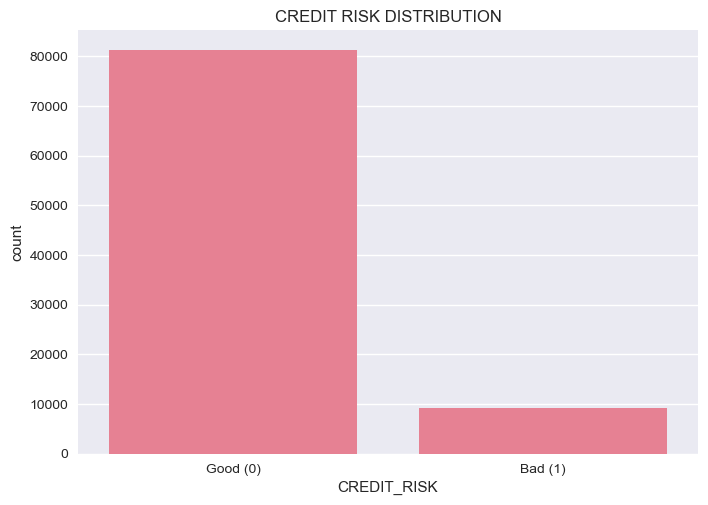

In [57]:
sns.countplot(data=df, x='CREDIT_RISK')
plt.title('Credit risk distribution')
plt.xticks([0, 1], ['Good (0)', 'Bad (1)'])

plt.title('CREDIT RISK DISTRIBUTION')
plt.show()

3.2. Correlation Matrix

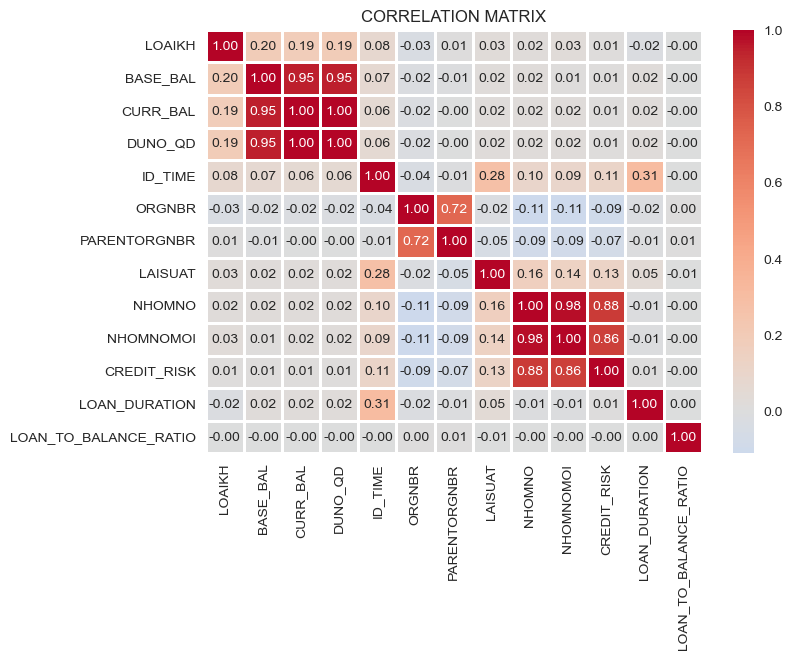

<Figure size 1600x1000 with 0 Axes>

In [58]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",annot_kws={"size": 10}, center=0,
            linewidths=1)
plt.title('CORRELATION MATRIX')
plt.figure(figsize=(16, 10))
plt.show()

3.3. Boxplot for variable distribution

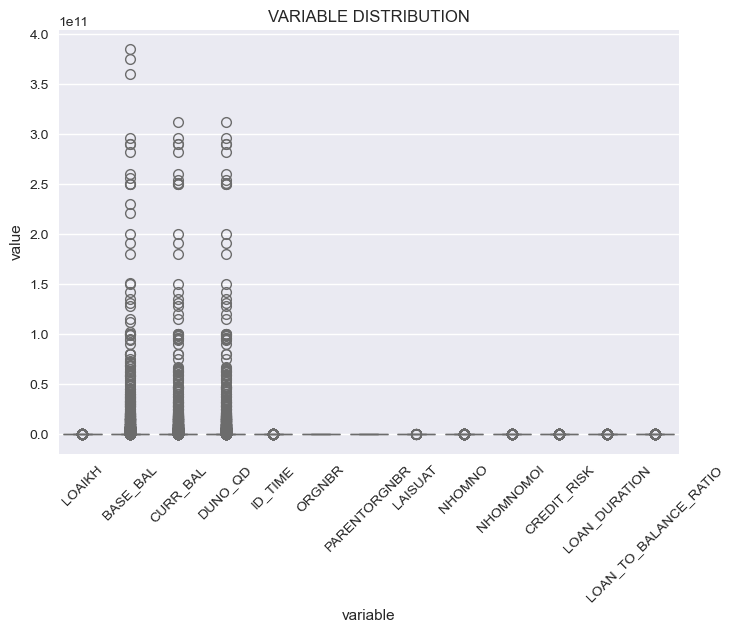

<Figure size 1600x1000 with 0 Axes>

In [59]:
df_melted = df[numeric_cols].melt()
sns.boxplot(data=df_melted, x='variable', y='value')
plt.title('Phân Phối Các Biến Số')
plt.tick_params(axis='x', rotation=45)

plt.title('VARIABLE DISTRIBUTION')
plt.figure(figsize=(16, 10))
plt.show()

3.4. Histogram of age distribution by credit risk (cần xem lại)

In [60]:
'''
for risk in [0, 1]:
    subset = df[df['CREDIT_RISK'] == risk]
    plt.hist(subset['SEX'], alpha=0.7, label=f'Risk {risk}', bins=20)
plt.title('Phân Phối GIỚI TÍNH theo Rủi Ro')
plt.legend()
'''

"\nfor risk in [0, 1]:\n    subset = df[df['CREDIT_RISK'] == risk]\n    plt.hist(subset['SEX'], alpha=0.7, label=f'Risk {risk}', bins=20)\nplt.title('Phân Phối GIỚI TÍNH theo Rủi Ro')\nplt.legend()\n"

3.5. Scatter plot interest rate vs loan duration

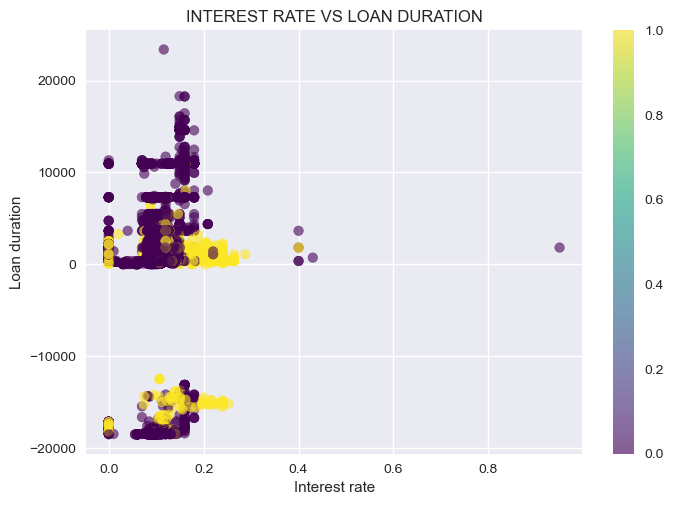

In [61]:
scatter = plt.scatter(df['LAISUAT'], df['LOAN_DURATION'], 
                           c=df['CREDIT_RISK'], cmap='viridis', alpha=0.6)
plt.title('INTEREST RATE VS LOAN DURATION')
plt.xlabel('Interest rate')
plt.ylabel('Loan duration')
plt.colorbar(scatter)

3.6. Missing data

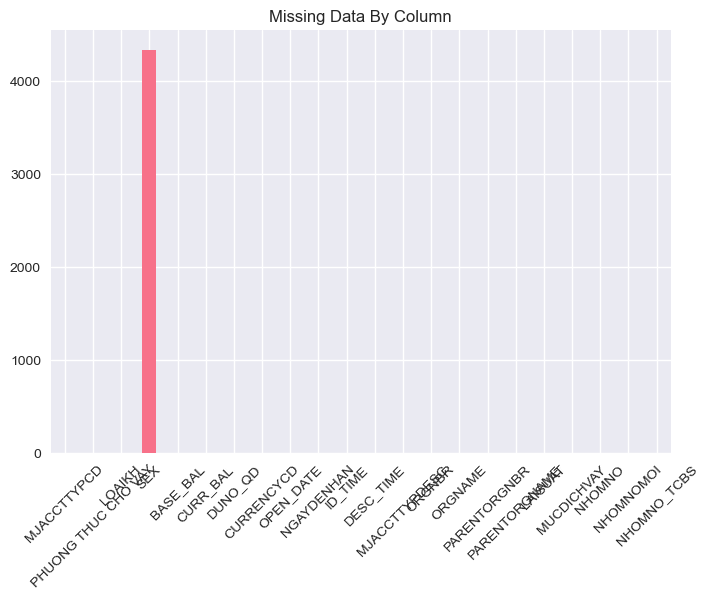

<Figure size 1600x1000 with 0 Axes>

In [62]:
missing_data.plot(kind='bar')
plt.title('Missing Data By Column')
plt.tick_params(axis='x', rotation=45)
plt.figure(figsize=(16, 10))
plt.tight_layout()
plt.show()

# 4. DATA PRE-PROCESSING

In [63]:
df_processed = df.copy()

4.1. Missing data handling

In [64]:
print("=== MISSING DATA PROCESSING ===")

# Xử lý biến số: using median
numeric_columns = df_processed.select_dtypes(include=[np.number]).columns
numeric_imputer = SimpleImputer(strategy='median')
df_processed[numeric_columns] = numeric_imputer.fit_transform(df_processed[numeric_columns])

# Xử lý biến phân loại: using mode
categorical_columns = df_processed.select_dtypes(include=['object']).columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
df_processed[categorical_columns] = categorical_imputer.fit_transform(df_processed[categorical_columns])

print("Missing data processed")

=== MISSING DATA PROCESSING ===
Missing data processed


4.2 Detect and handing outliers (IQR method)

In [65]:
print("\n=== PROCESSING OUTLIERS ===")
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Áp dụng cho các biến số quan trọng
original_size = len(df_processed)
for col in ['LAISUAT', 'LOAN_DURATION']:
    if col in df_processed.columns:
        df_processed = remove_outliers_iqr(df_processed, col)

print(f"Data size after removing outliers: {len(df_processed)} (reduce {original_size - len(df_processed)} sample)")


=== PROCESSING OUTLIERS ===
Data size after removing outliers: 83218 (reduce 7126 sample)


4.3 Categorical variable encoding

In [66]:
print("\n=== CATEGORICAL VARIABLE ENCONDING ===")
# Label encoding cho biến ordinal
label_encoders = {}
ordinal_columns = ['SEX', 'DESC_TIME'] 

for col in ordinal_columns:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
        label_encoders[col] = le

# One-hot encoding cho biến nominal
nominal_columns = ['MUCDICHVAY', 'MJACCTTYPDESC', 'PHUONG THUC CHO VAY', 'MJACCTTYPCD','NHOMNO_TCBS','ORGNAME']
df_encoded = pd.get_dummies(df_processed, columns=nominal_columns, prefix=nominal_columns)

print("Categorical variable encoding completed")


=== CATEGORICAL VARIABLE ENCONDING ===
Categorical variable encoding completed


4.4. Feature Engineering

In [67]:
df["LOAN_DURATION_RATIO"] = df["LOAN_DURATION"] / df["LOAN_DURATION"].mean()

# One-hot encode các biến mới
df_final = pd.get_dummies(df_encoded, columns=['SEX', 'DESC_TIME'])

print("New features created")

# Đặc trưng về thời hạn vay, phân loại thời hạn vay tín dụng

New features created


# 5. PREPARING DATA FOR MODELS

In [68]:
print("=== PREPARING DATA FOR MODELS ===")
if 'CURRENCYCD' in df_final.columns:
    df_final = df_final.drop(columns=['CURRENCYCD'])
print("Missing values before cleaning:")
print(df_final.isnull().sum().sum())
df_final = df_final.dropna() 
print(f"Data shape after cleaning: {df_final.shape}")
feature_columns = [col for col in df_final.columns if col not in ['CREDIT_RISK']]
X = df_final[feature_columns]
y = df_final['CREDIT_RISK']

=== PREPARING DATA FOR MODELS ===
Missing values before cleaning:
33259
Data shape after cleaning: (49959, 303)


In [69]:
feature_columns = [col for col in df_final.columns if col not in ['CREDIT_RISK']]
X = df_final[feature_columns]
y = df_final['CREDIT_RISK']

# Kiểm tra cân bằng dữ liệu
print("=== CHECK DATA BALANCE ===")
print(f"Number of good samples credit (0): {sum(y == 0)}")
print(f"Number of bad samples credit (1): {sum(y == 1)}")
print(f"Imbalance ratio: {sum(y == 1) / sum(y == 0):.3f}")

# Chia dữ liệu train/validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, 
                                                  random_state=42, stratify=y)

print(df_final[X.columns].isnull().sum())
df_final.dropna(inplace=True)

=== CHECK DATA BALANCE ===
Number of good samples credit (0): 44662
Number of bad samples credit (1): 5297
Imbalance ratio: 0.119
LOAIKH                     0
BASE_BAL                   0
CURR_BAL                   0
DUNO_QD                    0
OPEN_DATE                  0
                          ..
SEX_MS                     0
SEX_ONG                    0
DESC_TIME_Vay dai han      0
DESC_TIME_Vay ngan han     0
DESC_TIME_Vay trung han    0
Length: 302, dtype: int64


In [70]:
print(X_train.dtypes)
print(X_train.head())
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

LOAIKH                            float64
BASE_BAL                          float64
CURR_BAL                          float64
DUNO_QD                           float64
OPEN_DATE                  datetime64[ns]
                                ...      
SEX_MS                               bool
SEX_ONG                              bool
DESC_TIME_Vay dai han                bool
DESC_TIME_Vay ngan han               bool
DESC_TIME_Vay trung han              bool
Length: 302, dtype: object
       LOAIKH     BASE_BAL     CURR_BAL      DUNO_QD  OPEN_DATE NGAYDENHAN  \
14876     1.0  200000000.0  200000000.0  200000000.0 2018-06-28 2022-06-28   
23846     1.0   90000000.0   85000000.0   85000000.0 2019-05-13 2022-05-13   
39094     1.0  400000000.0  400000000.0  400000000.0 2019-09-18 2020-09-18   
49344     1.0  250000000.0  250000000.0  250000000.0 2019-12-24 2020-12-24   
53027     1.0   30000000.0   30000000.0   30000000.0 2019-12-18 2020-12-18   

       ID_TIME  ORGNBR  PARENTORGNBR      

In [71]:
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_val = X_val.apply(pd.to_numeric, errors="coerce")
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

In [72]:
# Chuẩn hóa dữ liệu

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

imputer = SimpleImputer(strategy='mean')  # hoặc 'median', 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

# Sau đó scale
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
print(pd.DataFrame(X_train).isnull().sum())
'''
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
'''
X.fillna(0, inplace=True)

print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập validation: {X_val.shape}")

LOAIKH                     0
BASE_BAL                   0
CURR_BAL                   0
DUNO_QD                    0
OPEN_DATE                  0
                          ..
SEX_MS                     0
SEX_ONG                    0
DESC_TIME_Vay dai han      0
DESC_TIME_Vay ngan han     0
DESC_TIME_Vay trung han    0
Length: 302, dtype: int64
Kích thước tập train: (34971, 302)
Kích thước tập validation: (14988, 302)


In [73]:
print("Pre-training validation:")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Contains NaN: {np.isnan(X_train_scaled).any()}")
print(f"Contains Inf: {np.isinf(X_train_scaled).any()}")

Pre-training validation:
X_train_scaled shape: (34971, 302)
y_train shape: (34971,)
Contains NaN: False
Contains Inf: False


# 6. MODEL BUILDING AND TRAINING

6.1 Logistic Regression (Traditional model)

In [74]:
print("=== LOGISTIC REGRESSION ===")

X_train_scaled = X_train.fillna(0)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Detect

lr_pred = lr_model.predict(X_val_scaled)
lr_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]

print("Model training completed successfully!")

=== LOGISTIC REGRESSION ===
Model training completed successfully!


6.2 Random Forest

In [75]:
print("\n=== RANDOM FOREST ===")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Detect
rf_pred = rf_model.predict(X_val)
rf_pred_proba = rf_model.predict_proba(X_val)[:, 1]
print("Model training completed successfully!")


=== RANDOM FOREST ===
Model training completed successfully!


6.3. Neural Network

In [76]:
print("\n=== NEURAL NETWORK ===")
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=500)
nn_model.fit(X_train_scaled, y_train)

# Dự đoán
nn_pred = nn_model.predict(X_val_scaled)
nn_pred_proba = nn_model.predict_proba(X_val_scaled)[:, 1]
print("All model training completed successfully!")


=== NEURAL NETWORK ===
All model training completed successfully!


# 7. ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH

In [77]:
# Tạo hàm đánh giá
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    print(f"\n=== ĐÁNH GIÁ MÔ HÌNH: {model_name} ===")
    
    # Các metrics cơ bản
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc_roc
    }

In [78]:
# Đánh giá từng mô hình
lr_metrics = evaluate_model(y_val, lr_pred, lr_pred_proba, "Logistic Regression")
rf_metrics = evaluate_model(y_val, rf_pred, rf_pred_proba, "Random Forest")
nn_metrics = evaluate_model(y_val, nn_pred, nn_pred_proba, "Neural Network")


=== ĐÁNH GIÁ MÔ HÌNH: Logistic Regression ===
Accuracy: 0.5967
Precision: 0.1616
Recall: 0.6696
F1-Score: 0.2604
AUC-ROC: 0.5000

Confusion Matrix:
[[7880 5519]
 [ 525 1064]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.59      0.72     13399
         1.0       0.16      0.67      0.26      1589

    accuracy                           0.60     14988
   macro avg       0.55      0.63      0.49     14988
weighted avg       0.86      0.60      0.67     14988


=== ĐÁNH GIÁ MÔ HÌNH: Random Forest ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
AUC-ROC: 1.0000

Confusion Matrix:
[[13399     0]
 [    0  1589]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     13399
         1.0       1.00      1.00      1.00      1589

    accuracy                           1.00     14988
   macro avg       1.00      1.00      1.00     14988
wei

# 8. COMPARE AND VISUALIZE RESULTS

=== PERFORMANCE COMPARISON TABLE ===
                     accuracy  precision  recall  f1_score  auc_roc
Logistic Regression    0.5967     0.1616  0.6696    0.2604   0.5000
Neural Network         0.7665     0.2991  0.8949    0.4484   0.9214


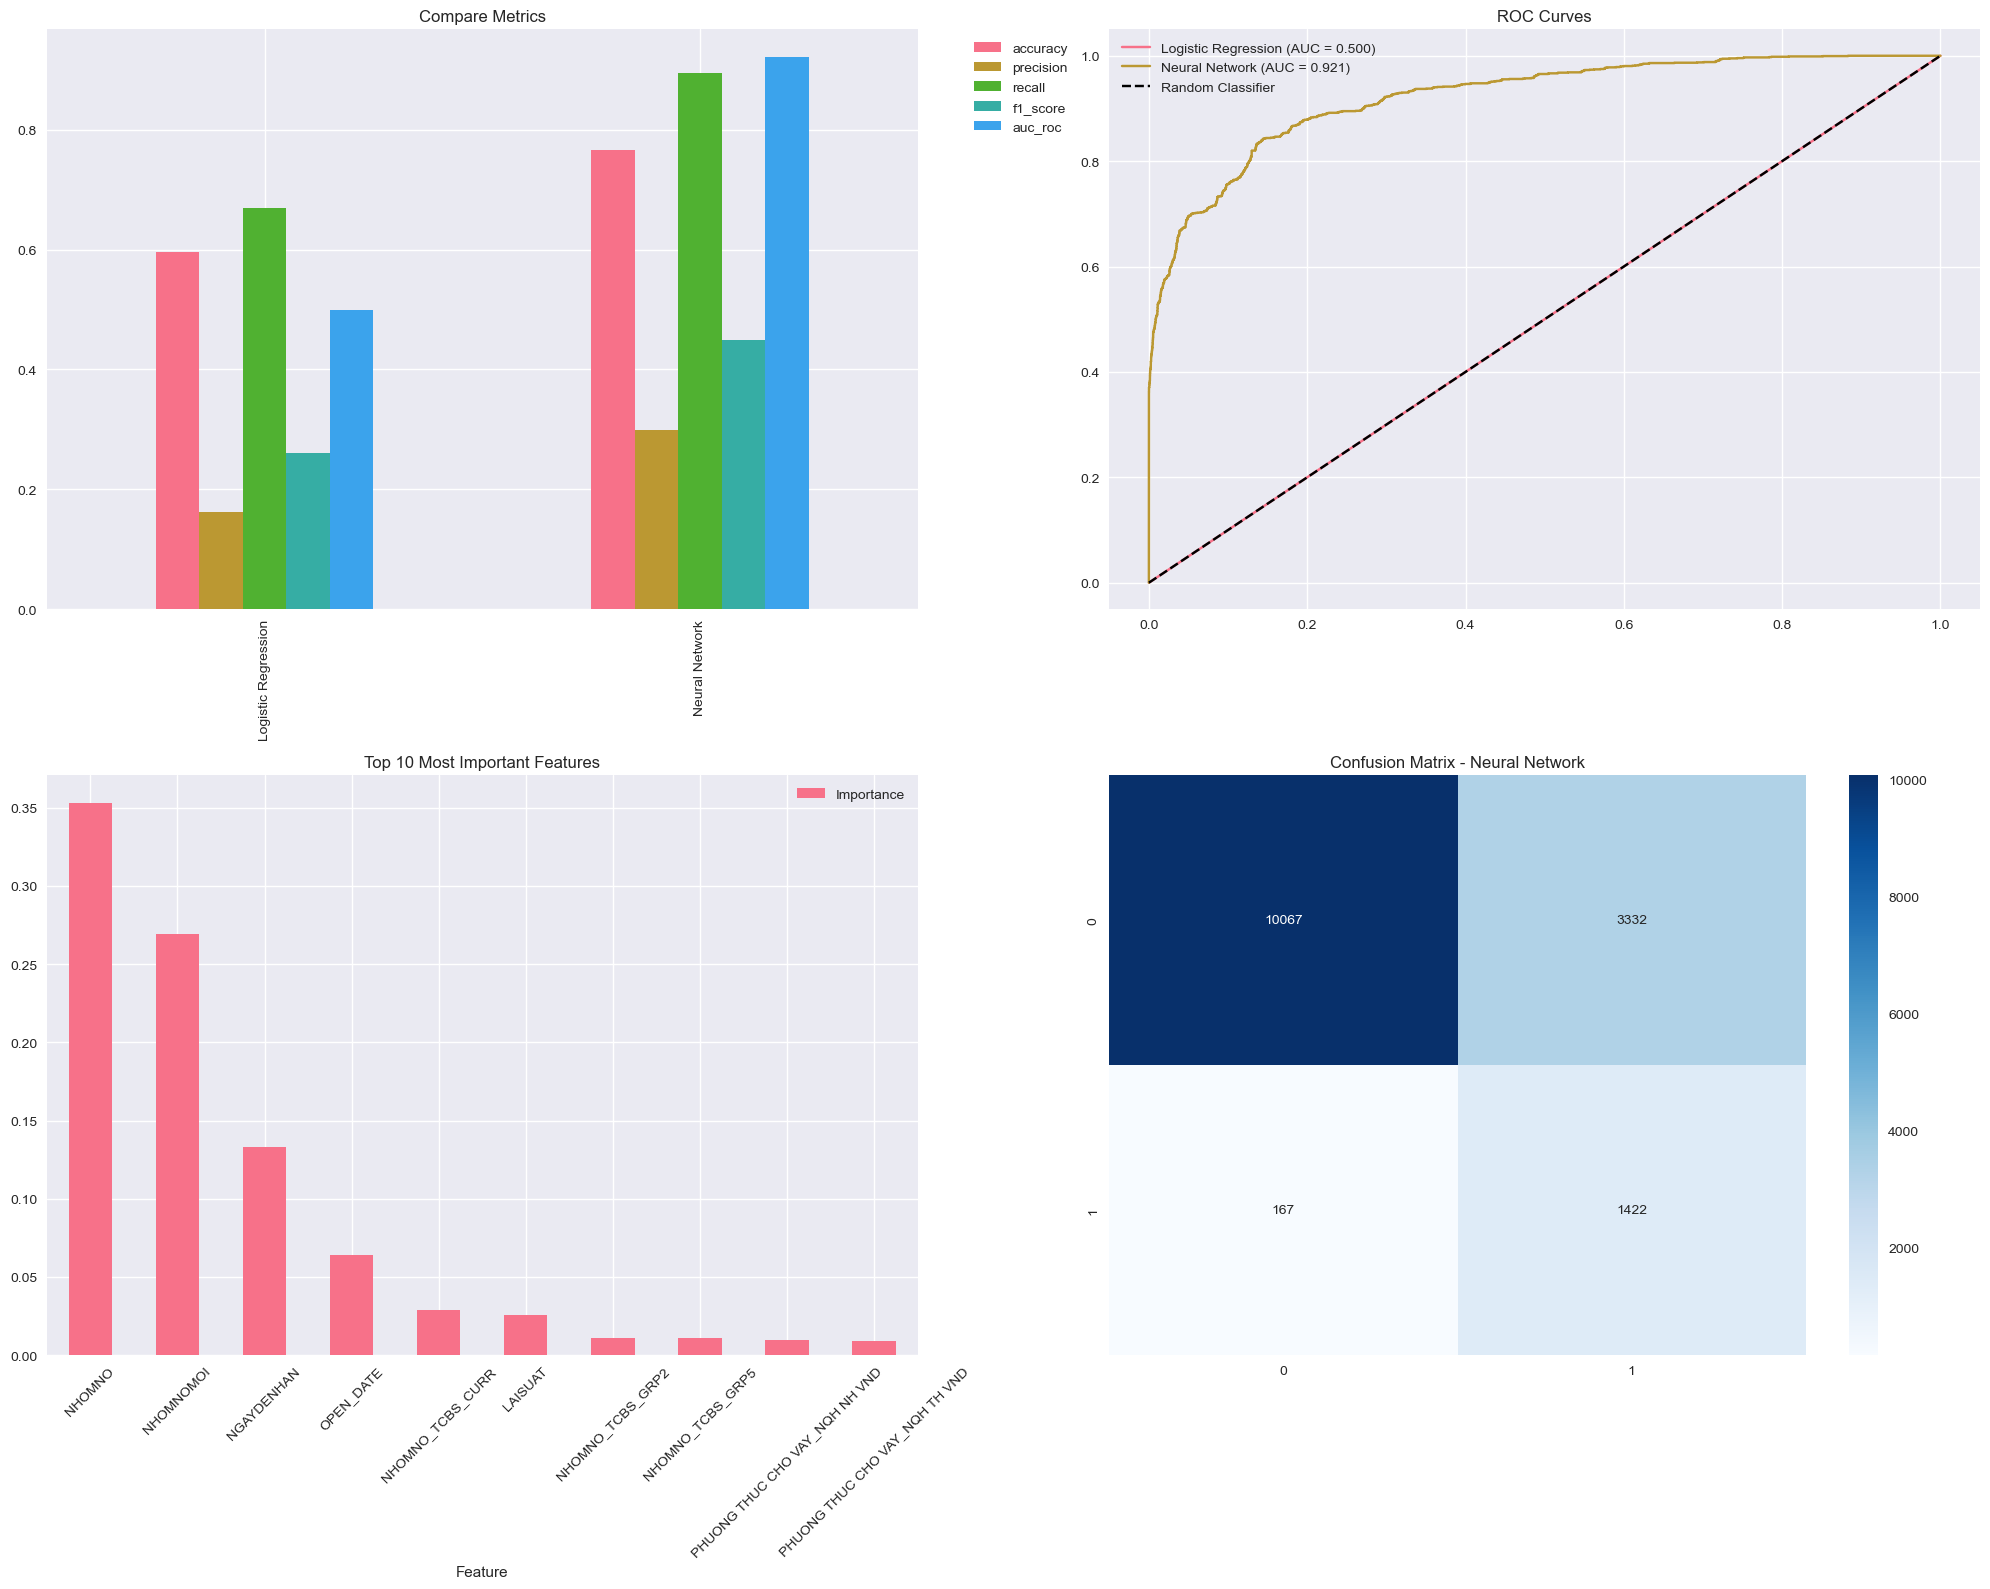

In [79]:
# Tạo bảng so sánh
results_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Neural Network': nn_metrics
}).T

print("=== PERFORMANCE COMPARISON TABLE ===")
print(results_df.round(4))

# Biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. So sánh metrics
results_df.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Compare Metrics')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_pred_proba)
fpr_nn, tpr_nn, _ = roc_curve(y_val, nn_pred_proba)

axes[0,1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["auc_roc"]:.3f})')

axes[0,1].plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {nn_metrics["auc_roc"]:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0,1].set_title('ROC Curves')
axes[0,1].legend()

# 3. Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

feature_importance.plot(x='Feature', y='Importance', kind='bar', ax=axes[1,0])
axes[1,0].set_title('Top 10 Most Important Features')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Confusion Matrix Heatmap (Best Model)
best_model_name = results_df['auc_roc'].idxmax()
if best_model_name == 'Random Forest':
    best_pred = rf_pred
else:
    best_pred = lr_pred if best_model_name == 'Logistic Regression' else nn_pred

cm = confusion_matrix(y_val, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title(f'Confusion Matrix - {best_model_name}')

plt.tight_layout()
plt.show()

# 9. PREDICTION ON VALIDATION SET

In [80]:
# Chọn mô hình tốt nhất
best_model_name = results_df['auc_roc'].idxmax()
print(f"=== THE BEST MODEL: {best_model_name} ===")

if best_model_name == 'Neural Network':
    best_model = nn_model
    best_predictions = nn_pred
    best_probabilities = nn_pred_proba
elif best_model_name == 'Logistic Regression':
    best_model = lr_model
    best_predictions = lr_pred
    best_probabilities = lr_pred_proba
else:
    best_model = nn_model
    best_predictions = nn_pred
    best_probabilities = nn_pred_proba

# Tạo DataFrame kết quả
validation_results = pd.DataFrame({
    'Actual': y_val,
    'Predicted': best_predictions,
    'Probability': best_probabilities
})

# Thêm customer profile labels
validation_results['Customer_Profile'] = validation_results['Probability'].apply(
    lambda x: 'High Risk' if x > 0.7 else ('Medium Risk' if x > 0.3 else 'Low Risk')
)

print("\n=== PREDICTION RESULTS ON VALIDATION SET ===")
print(validation_results.head(10))

# Phân tích profile
profile_analysis = validation_results.groupby('Customer_Profile').agg({
    'Actual': ['count', 'mean'],
    'Probability': ['mean', 'std']
}).round(4)

print("\n=== CUSTOMER PROFILE ANALYSIS ===")
print(profile_analysis)

=== THE BEST MODEL: Neural Network ===

=== PREDICTION RESULTS ON VALIDATION SET ===
       Actual  Predicted  Probability Customer_Profile
47741     0.0        0.0     0.074788         Low Risk
1676      0.0        0.0     0.433354      Medium Risk
56930     0.0        1.0     0.677571      Medium Risk
380       1.0        1.0     1.000000        High Risk
68794     0.0        0.0     0.029385         Low Risk
3458      1.0        1.0     1.000000        High Risk
14589     0.0        0.0     0.018902         Low Risk
60149     1.0        0.0     0.365561      Medium Risk
16476     0.0        0.0     0.040755         Low Risk
22858     0.0        0.0     0.020692         Low Risk

=== CUSTOMER PROFILE ANALYSIS ===
                 Actual         Probability        
                  count    mean        mean     std
Customer_Profile                                   
High Risk          3240  0.4117      0.9236  0.0880
Low Risk           8261  0.0109      0.0566  0.0749
Medium Risk    

# 10. CONCLUSION AND RECOMMENDATIONS

In [81]:
print("=" * 60)
print("KẾT LUẬN VÀ KHUYẾN NGHỊ")
print("=" * 60)

print(f"\n1. MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"   - AUC-ROC: {results_df.loc[best_model_name, 'auc_roc']:.4f}")
print(f"   - Accuracy: {results_df.loc[best_model_name, 'accuracy']:.4f}")
print(f"   - F1-Score: {results_df.loc[best_model_name, 'f1_score']:.4f}")

print(f"\n2. ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
top_features = feature_importance.head(5)
for idx, row in top_features.iterrows():
    print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print(f"\n3. HIỆU SUẤT PHÂN LOẠI:")
print(f"   - High Risk customers: {len(validation_results[validation_results['Customer_Profile'] == 'High Risk'])} khách hàng")
print(f"   - Medium Risk customers: {len(validation_results[validation_results['Customer_Profile'] == 'Medium Risk'])} khách hàng")
print(f"   - Low Risk customers: {len(validation_results[validation_results['Customer_Profile'] == 'Low Risk'])} khách hàng")

print(f"\n4. KHUYẾN NGHỊ:")
print(f"   - Sử dụng {best_model_name} cho dự đoán rủi ro tín dụng")
print(f"   - Tập trung vào các đặc trưng: {', '.join(top_features['Feature'].head(4).tolist())}")
print(f"   - Thiết lập ngưỡng rủi ro dựa trên phân tích Customer Profile")
print(f"   - Thực hiện validation định kỳ để duy trì hiệu suất mô hình")

KẾT LUẬN VÀ KHUYẾN NGHỊ

1. MÔ HÌNH TỐT NHẤT: Neural Network
   - AUC-ROC: 0.9214
   - Accuracy: 0.7665
   - F1-Score: 0.4484

2. ĐẶC TRƯNG QUAN TRỌNG NHẤT:
   - NHOMNO: 0.3530
   - NHOMNOMOI: 0.2691
   - NGAYDENHAN: 0.1334
   - OPEN_DATE: 0.0642
   - NHOMNO_TCBS_CURR: 0.0290

3. HIỆU SUẤT PHÂN LOẠI:
   - High Risk customers: 3240 khách hàng
   - Medium Risk customers: 3487 khách hàng
   - Low Risk customers: 8261 khách hàng

4. KHUYẾN NGHỊ:
   - Sử dụng Neural Network cho dự đoán rủi ro tín dụng
   - Tập trung vào các đặc trưng: NHOMNO, NHOMNOMOI, NGAYDENHAN, OPEN_DATE
   - Thiết lập ngưỡng rủi ro dựa trên phân tích Customer Profile
   - Thực hiện validation định kỳ để duy trì hiệu suất mô hình


# 11. LƯU KẾT QUẢ

In [82]:
# Lưu mô hình tốt nhất
import joblib
joblib.dump(best_model, f'best_credit_risk_model_{best_model_name.lower().replace(" ", "_")}.pkl')
joblib.dump(scaler, 'credit_risk_scaler.pkl')

# Lưu kết quả validation
validation_results.to_csv('validation_results.csv', index=False)
results_df.to_csv('model_comparison_results.csv')

# Lưu feature importance
feature_importance.to_csv('feature_importance.csv', index=False)

print("Đã lưu tất cả kết quả và mô hình!")

Đã lưu tất cả kết quả và mô hình!
